In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# EXPLAINABILITY

Faithfulness score

In [ ]:
import os
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.optimizers.schedules import CosineDecayRestarts

# Define the path to your model file
model_path = "/content/drive/MyDrive/saved_models/bilstm_final.keras"

# Check if the file exists
if os.path.exists(model_path):
    try:
        # Load the model with custom objects and the safe_mode=False flag
        bilstm_model_final = load_model(
            model_path,
            custom_objects={
                'AdamW': AdamW,
                'CosineDecayRestarts': CosineDecayRestarts
            },
            safe_mode=False
        )
        print("✅ BiLSTM model loaded successfully!")
    except Exception as e:
        print(f"❌ Error loading BiLSTM model: {e}")
else:
    print(f"❌ Model file not found at: {model_path}")

✅ BiLSTM model loaded successfully!


In [ ]:
import os
import torch
import torch.nn as nn
import numpy as np
import pickle
from sklearn.preprocessing import LabelEncoder
from torch.nn import GLU, ReLU, Linear, Conv1d, LayerNorm, Dropout, AdaptiveAvgPool1d, Sigmoid, MultiheadAttention
from torch.nn.functional import softplus, relu, softmax, tanh
from torch.utils.data import DataLoader, TensorDataset

# --- Re-define the necessary classes from your code ---
# You need all the model components to instantiate the class
class Mish(nn.Module):
    def forward(self, x): return x * torch.tanh(F.softplus(x))
class PositionalEncoding(nn.Module):
    def __init__(self, dim, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, dim)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, dim, 2).float() * -(np.log(10000.0) / dim))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x): return x + self.pe[:, :x.size(1)]
class SEBlock(nn.Module):
    def __init__(self, dim, reduction=16):
        super().__init__()
        self.se = nn.Sequential(nn.AdaptiveAvgPool1d(1), nn.Conv1d(dim, dim // reduction, 1), nn.ReLU(), nn.Conv1d(dim // reduction, dim, 1), nn.Sigmoid())
    def forward(self, x):
        x = x.transpose(1, 2)
        scale = self.se(x)
        x = x * scale
        return x.transpose(1, 2)
class FeedForwardModule(nn.Module):
    def __init__(self, dim, expansion=4, dropout=0.4):
        super().__init__()
        self.net = nn.Sequential(nn.LayerNorm(dim), nn.Linear(dim, dim * expansion), Mish(), nn.Dropout(dropout), nn.Linear(dim * expansion, dim), nn.Dropout(dropout))
    def forward(self, x): return x + 0.5 * self.net(x)
class ConvolutionModule(nn.Module):
    def __init__(self, dim, kernel_size=31):
        super().__init__()
        self.pointwise1 = nn.Conv1d(dim, 2 * dim, kernel_size=1)
        self.glu = nn.GLU(dim=1)
        self.depthwise = nn.Conv1d(dim, dim, kernel_size=kernel_size, padding=kernel_size // 2, groups=dim)
        self.bn = nn.BatchNorm1d(dim)
        self.act = Mish()
        self.pointwise2 = nn.Conv1d(dim, dim, kernel_size=1)
    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.pointwise1(x)
        x = self.glu(x)
        x = self.depthwise(x)
        x = self.bn(x)
        x = self.act(x)
        x = self.pointwise2(x)
        return x.transpose(1, 2)
class ConformerBlock(nn.Module):
    def __init__(self, dim, heads=4, ff_expansion=4, conv_kernel=31, dropout=0.4):
        super().__init__()
        self.ff1 = FeedForwardModule(dim, ff_expansion, dropout)
        self.mha = nn.MultiheadAttention(embed_dim=dim, num_heads=heads, batch_first=True)
        self.norm1 = nn.LayerNorm(dim)
        self.conv = ConvolutionModule(dim, conv_kernel)
        self.norm2 = nn.LayerNorm(dim)
        self.ff2 = FeedForwardModule(dim, ff_expansion, dropout)
        self.norm3 = nn.LayerNorm(dim)
        self.se = SEBlock(dim)
    def forward(self, x):
        x = self.ff1(x)
        attn_out, _ = self.mha(x, x, x)
        x = self.norm1(x + attn_out)
        x = self.norm2(x + self.conv(x))
        x = self.ff2(x)
        x = self.se(x)
        return self.norm3(x)
class ConformerClassifier(nn.Module):
    def __init__(self, input_dim, model_dim=96, num_blocks=1, num_classes=7):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, model_dim)
        self.pos_enc = PositionalEncoding(model_dim)
        self.blocks = nn.ModuleList([ConformerBlock(model_dim, heads=4, ff_expansion=4, conv_kernel=31, dropout=0.4) for _ in range(num_blocks)])
        self.feature_layer = nn.Linear(model_dim, 128)
        self.classifier = nn.Sequential(nn.Linear(128, 64), nn.ReLU(), nn.Dropout(0.4), nn.Linear(64, num_classes))
    def forward(self, x, output_type='classification'):
        x = self.input_proj(x)
        x = self.pos_enc(x)
        for b in self.blocks: x = b(x)
        pooled = x.mean(dim=1)
        features = self.feature_layer(pooled)
        if output_type == 'features': return features
        elif output_type == 'classification': return self.classifier(features)
        else: raise ValueError("output_type must be 'classification' or 'features'")

# --- Load the data to get the correct dimensions ---
DATA_PATH_Y = "/content/drive/MyDrive/y_train_aug.pkl"
DATA_PATH_FEATURES = "/content/drive/MyDrive/feature_sets_dict.pkl"

def load_data():
    with open(DATA_PATH_Y, "rb") as f:
        y_train_aug = pickle.load(f)
    with open(DATA_PATH_FEATURES, "rb") as f:
        feature_sets = pickle.load(f)

    X_all = np.array(feature_sets["MFCC+MFDWC"])
    X_cleaned, y_cleaned = [], []
    for x, label in zip(X_all, y_train_aug):
        if label == "calm": continue
        if label == "surprised": label = "surprise"
        X_cleaned.append(x)
        y_cleaned.append(label)

    X_cleaned = np.array(X_cleaned)
    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(y_cleaned)
    return X_cleaned, y_encoded, None, label_encoder

X, y_int, _, label_encoder = load_data()

# --- Load the model using the correct dimensions ---
# Define the path to your model file
model_path = "/content/drive/MyDrive/saved_models/conformer_final.pt"

# Get the correct input dimension from your data
input_dim = X.shape[2]  # This will now correctly be 90
num_classes = len(np.unique(y_int)) # This will be 7

# Instantiate the model with the correct dimensions
conformer_model_final = ConformerClassifier(input_dim=input_dim, num_classes=num_classes)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
conformer_model_final.to(device)

# Check if the file exists and load the state_dict
if os.path.exists(model_path):
    try:
        conformer_model_final.load_state_dict(torch.load(model_path, map_location=device))
        print("✅ Conformer model loaded successfully!")
    except Exception as e:
        print(f"❌ Error loading Conformer model: {e}")
else:
    print(f"❌ Model file not found at: {model_path}")

# Set the model to evaluation mode
conformer_model_final.eval()

✅ Conformer model loaded successfully!


ConformerClassifier(
  (input_proj): Linear(in_features=90, out_features=96, bias=True)
  (pos_enc): PositionalEncoding()
  (blocks): ModuleList(
    (0): ConformerBlock(
      (ff1): FeedForwardModule(
        (net): Sequential(
          (0): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
          (1): Linear(in_features=96, out_features=384, bias=True)
          (2): Mish()
          (3): Dropout(p=0.4, inplace=False)
          (4): Linear(in_features=384, out_features=96, bias=True)
          (5): Dropout(p=0.4, inplace=False)
        )
      )
      (mha): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=96, out_features=96, bias=True)
      )
      (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
      (conv): ConvolutionModule(
        (pointwise1): Conv1d(96, 192, kernel_size=(1,), stride=(1,))
        (glu): GLU(dim=1)
        (depthwise): Conv1d(96, 96, kernel_size=(31,), stride=(1,), padding=(15,), groups=96)
        (bn

In [ ]:
import os
import torch
import torch.nn as nn

# Assuming you have the EnsembleModelTorch class defined in your notebook
# Paste the class definition here if it's not already
class EnsembleModelTorch(nn.Module):
    # ... (paste the entire class definition from your code)
    def __init__(self, fusion_method='add', num_classes=7):
        super().__init__()
        self.fusion_method = fusion_method
        if fusion_method in ['add', 'weighted_add', 'attention_scalar']: fused_dim = 128
        else: fused_dim = 256
        self.norm1 = nn.LayerNorm(128)
        self.norm2 = nn.LayerNorm(128)
        if fusion_method in ['weighted_add', 'weighted_concat']:
            self.weight1 = nn.Parameter(torch.tensor(0.5))
            self.weight2 = nn.Parameter(torch.tensor(0.5))
        if fusion_method == 'attention_soft':
            self.attention = nn.Sequential(nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.2), nn.Linear(128, 2), nn.Softmax(dim=1))
        elif fusion_method == 'attention_scalar':
            self.att_scalar = nn.Sequential(nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.2), nn.Linear(128, 1), nn.Sigmoid())
        self.classifier = nn.Sequential(nn.BatchNorm1d(fused_dim), nn.Linear(fused_dim, 64), nn.ReLU(), nn.Dropout(0.4), nn.Linear(64, num_classes))
    def forward(self, f1, f2):
        f1 = self.norm1(f1)
        f2 = self.norm2(f2)
        if self.fusion_method == 'add': fused = f1 + f2
        elif self.fusion_method == 'concat': fused = torch.cat([f1, f2], dim=1)
        elif self.fusion_method == 'weighted_add':
            w = torch.softmax(torch.stack([self.weight1, self.weight2]), dim=0)
            fused = w[0]*f1 + w[1]*f2
        elif self.fusion_method == 'weighted_concat':
            w = torch.softmax(torch.stack([self.weight1, self.weight2]), dim=0)
            fused = torch.cat([w[0]*f1, w[1]*f2], dim=1)
        elif self.fusion_method == 'attention_soft':
            cat = torch.cat([f1, f2], dim=1)
            att = self.attention(cat)
            fused = att[:,0:1]*f1 + att[:,1:2]*f2
        elif self.fusion_method == 'attention_scalar':
            cat = torch.cat([f1, f2], dim=1)
            s = self.att_scalar(cat)
            fused = s * f1 + (1-s) * f2
        return self.classifier(fused)

# List of fusion methods to load
fusion_methods = [
    'add',
    'concat',
    'weighted_add',
    'weighted_concat',
    'attention_scalar'
]

# A dictionary to store the loaded models
ensemble_models = {}
num_classes = 7 # Replace with the actual number of classes

for fusion in fusion_methods:
    model_path = f"/content/drive/MyDrive/saved_models/ensemble_{fusion}_final.pt"

    # Instantiate the model with the correct fusion method
    ensemble_model = EnsembleModelTorch(fusion_method=fusion, num_classes=num_classes)

    # Check if the file exists and load the state_dict
    if os.path.exists(model_path):
        try:
            ensemble_model.load_state_dict(torch.load(model_path))
            ensemble_models[fusion] = ensemble_model
            print(f"✅ Ensemble model for '{fusion}' loaded successfully!")
        except Exception as e:
            print(f"❌ Error loading '{fusion}' ensemble model: {e}")
    else:
        print(f"❌ Model file not found for '{fusion}' at: {model_path}")

# Example: Accessing a loaded model
if 'add' in ensemble_models:
    add_ensemble_model = ensemble_models['add']
    add_ensemble_model.eval() # Set to evaluation mode before use

✅ Ensemble model for 'add' loaded successfully!
✅ Ensemble model for 'concat' loaded successfully!
✅ Ensemble model for 'weighted_add' loaded successfully!
✅ Ensemble model for 'weighted_concat' loaded successfully!
✅ Ensemble model for 'attention_scalar' loaded successfully!


In [ ]:
!pip install shap
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=930df7c74fdd6bffae29b584fbed19d8788afeee3afb74338555fa7b6d1d7377
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [ ]:
import lime
import lime.lime_tabular
import numpy as np
import torch
import torch.nn.functional as F
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt

# Ensure all your models are loaded and in eval mode
# (Your previous code cells should have handled this)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

for fusion in ensemble_models:
    ensemble_models[fusion].to(device)
    ensemble_models[fusion].eval()

conformer_model_final.to(device)
conformer_model_final.eval()

ConformerClassifier(
  (input_proj): Linear(in_features=90, out_features=96, bias=True)
  (pos_enc): PositionalEncoding()
  (blocks): ModuleList(
    (0): ConformerBlock(
      (ff1): FeedForwardModule(
        (net): Sequential(
          (0): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
          (1): Linear(in_features=96, out_features=384, bias=True)
          (2): Mish()
          (3): Dropout(p=0.4, inplace=False)
          (4): Linear(in_features=384, out_features=96, bias=True)
          (5): Dropout(p=0.4, inplace=False)
        )
      )
      (mha): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=96, out_features=96, bias=True)
      )
      (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
      (conv): ConvolutionModule(
        (pointwise1): Conv1d(96, 192, kernel_size=(1,), stride=(1,))
        (glu): GLU(dim=1)
        (depthwise): Conv1d(96, 96, kernel_size=(31,), stride=(1,), padding=(15,), groups=96)
        (bn

In [ ]:
# The BiLSTM feature model's output is the 'features' layer from your original architecture
bilstm_feature_model = Model(
    inputs=bilstm_model_final.input,
    outputs=bilstm_model_final.get_layer('features').output
)

print("✅ BiLSTM feature extractor is ready.")

# We also need the helper function to extract conformer features (from your original code)
def extract_conformer_features(model, X_data, device=None, batch_size=64):
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.eval()
    X_tensor = torch.tensor(X_data, dtype=torch.float32).to(device)
    feats = []
    with torch.no_grad():
        for i in range(0, len(X_tensor), batch_size):
            batch = X_tensor[i : i + batch_size]
            # Use the feature extraction mode of the conformer
            f = model(batch, output_type='features')
            feats.append(f.cpu().numpy())
    return np.vstack(feats)

print("Conformer feature extraction helper is ready.")

✅ BiLSTM feature extractor is ready.
Conformer feature extraction helper is ready.


In [ ]:
# Choose which fusion model you want to explain
FUSION_METHOD_TO_EXPLAIN = 'concat'
chosen_ensemble_model = ensemble_models[FUSION_METHOD_TO_EXPLAIN]

def predict_proba(numpy_data):
    """
    This function takes numpy data, runs it through the full pipeline,
    and returns class probabilities.
    LIME will call this function repeatedly.
    """
    # LIME works with 1D flattened data, so we need to reshape it back
    # to the original 2D shape (timesteps, features)
    num_samples = numpy_data.shape[0]
    original_shape = (num_samples, X.shape[1], X.shape[2]) # (batch, 250, 90)
    numpy_data_2d = numpy_data.reshape(original_shape)

    # --- Stage 1: BiLSTM Feature Extraction ---
    feats_bilstm = bilstm_feature_model.predict(numpy_data_2d, verbose=0)

    # --- Stage 2: Conformer Feature Extraction ---
    feats_conf = extract_conformer_features(conformer_model_final, numpy_data_2d, device=device)

    # --- Stage 3: Ensemble Prediction ---
    # Convert features to torch tensors for the ensemble model
    f1 = torch.tensor(feats_bilstm, dtype=torch.float32).to(device)
    f2 = torch.tensor(feats_conf, dtype=torch.float32).to(device)

    # Get the model's output (logits)
    with torch.no_grad():
        logits = chosen_ensemble_model(f1, f2)

    # Convert logits to probabilities using softmax
    probabilities = F.softmax(logits, dim=1)

    # Return probabilities as a numpy array, as LIME expects
    return probabilities.detach().cpu().numpy()

print(f"✅ Master prediction function created for '{FUSION_METHOD_TO_EXPLAIN}' fusion model.")

✅ Master prediction function created for 'concat' fusion model.


In [ ]:
# =========================================================================
# EXPLAINABILITY SUITE FOR BiLSTM + CONFORMER ENSEMBLE
# Includes: SHAP, LIME, and Trustworthy XAI Metrics
# =========================================================================

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# -------------------------------------------------------------------------
# SECTION 1: SHAP EXPLANATIONS (FAST GRADIENT-BASED)
# -------------------------------------------------------------------------
print("📦 Installing SHAP...")
!pip install shap -q

import shap

class SHAPExplainer:
    """
    SHAP explainer using integrated gradients (fast and reliable).
    """
    def __init__(self, bilstm_feature_model, conformer_model, ensemble_model, device):
        self.bilstm_feature_model = bilstm_feature_model
        self.conformer_model = conformer_model
        self.ensemble_model = ensemble_model
        self.device = device

    def compute_integrated_gradients(self, X_sample, baseline, predict_fn, num_steps=50):
        """
        Compute integrated gradients - a fast gradient-based attribution method.
        Similar to SHAP but much faster.
        """
        # Get prediction
        pred = predict_fn(X_sample.reshape(1, *X_sample.shape))
        pred_class = np.argmax(pred[0])
        num_classes = pred.shape[1]

        # Create path from baseline to input
        alphas = np.linspace(0, 1, num_steps)

        # Store gradients
        timesteps, features = X_sample.shape
        integrated_grads = np.zeros((num_classes, timesteps, features))

        for alpha in alphas:
            # Interpolate between baseline and input
            X_interpolated = baseline + alpha * (X_sample - baseline)

            # Convert to tensor with gradient tracking
            X_tensor = torch.tensor(X_interpolated.reshape(1, timesteps, features),
                                   dtype=torch.float32, requires_grad=True).to(self.device)

            # Forward pass through models
            # BiLSTM (can't compute gradients through Keras)
            feats_bilstm = self.bilstm_feature_model.predict(
                X_tensor.detach().cpu().numpy(), verbose=0
            )
            feats_bilstm = torch.tensor(feats_bilstm, dtype=torch.float32).to(self.device)

            # Conformer (with gradients)
            self.conformer_model.eval()
            feats_conf = self.conformer_model(X_tensor, output_type='features')

            # Ensemble
            self.ensemble_model.eval()
            logits = self.ensemble_model(feats_bilstm, feats_conf)

            # Compute gradients for each class
            for c in range(num_classes):
                if X_tensor.grad is not None:
                    X_tensor.grad.zero_()

                # Backward pass
                logits[0, c].backward(retain_graph=True)

                if X_tensor.grad is not None:
                    integrated_grads[c] += X_tensor.grad[0].detach().cpu().numpy()

        # Average gradients and multiply by (input - baseline)
        integrated_grads /= num_steps
        integrated_grads *= (X_sample - baseline)

        return integrated_grads

    def explain_samples(self, X_background, X_test_samples, class_names, max_display=10, nsamples=50):
        """
        Generate attribution scores using integrated gradients (FAST).

        Args:
            X_background: Used to compute baseline (mean)
            X_test_samples: Samples to explain
            class_names: List of emotion labels
            max_display: Number of samples to display
            nsamples: Number of integration steps (default 50 is good)
        """
        print("\n🔍 Computing Feature Attribution (Integrated Gradients - FAST!)...")
        print(f"   Analyzing {max_display} samples...")

        # Compute baseline (mean of background)
        baseline = np.mean(X_background, axis=0)

        predict_fn = self.create_prediction_function()

        # Compute attributions for each sample
        all_attributions = []

        from tqdm import tqdm
        for i in tqdm(range(min(max_display, len(X_test_samples))), desc="   Computing attributions"):
            X_sample = X_test_samples[i]

            try:
                attribution = self.compute_integrated_gradients(
                    X_sample, baseline, predict_fn, num_steps=nsamples
                )
                all_attributions.append(attribution)
            except Exception as e:
                print(f"\n   ⚠️ Warning: Could not compute gradients for sample {i}: {e}")
                print("   Using simpler perturbation method for this sample...")
                attribution = self.simple_perturbation(X_sample, baseline, predict_fn)
                all_attributions.append(attribution)

        print(f"\n   ✅ Attributions computed for {len(all_attributions)} samples!")

        # Format output as list of arrays [class_0, class_1, ...]
        num_classes = all_attributions[0].shape[0]
        shap_values = []

        for class_idx in range(num_classes):
            class_scores = np.array([attr[class_idx] for attr in all_attributions])
            shap_values.append(class_scores)

        return shap_values, X_test_samples[:max_display]

    def simple_perturbation(self, X_sample, baseline, predict_fn, num_perturbations=20):
        """
        Fallback: Simple perturbation-based attribution (faster version).
        Only perturbs high-variance features.
        """
        pred = predict_fn(X_sample.reshape(1, *X_sample.shape))
        num_classes = pred.shape[1]

        timesteps, features = X_sample.shape
        importance = np.zeros((num_classes, timesteps, features))

        # Find most variable features (top 20%)
        variance = np.var(X_sample, axis=0)
        top_features = np.argsort(variance)[-int(features * 0.2):]

        for f in top_features:
            for t in range(0, timesteps, 2):  # Skip every other timestep for speed
                deltas = []
                for _ in range(num_perturbations):
                    X_pert = X_sample.copy()
                    X_pert[t, f] = baseline[t, f]
                    pred_pert = predict_fn(X_pert.reshape(1, *X_pert.shape))
                    deltas.append(pred[0] - pred_pert[0])

                importance[:, t, f] = np.mean(deltas, axis=0)

        return importance

    def create_prediction_function(self):
        """Create prediction function for the pipeline."""
        def predict_fn(X_3d):
            if len(X_3d.shape) == 2:
                X_3d = X_3d.reshape(1, X_3d.shape[0], X_3d.shape[1])

            feats_bilstm = self.bilstm_feature_model.predict(X_3d, verbose=0)

            X_tensor = torch.tensor(X_3d, dtype=torch.float32).to(self.device)
            self.conformer_model.eval()
            with torch.no_grad():
                feats_conf = self.conformer_model(X_tensor, output_type='features')
                feats_conf = feats_conf.cpu().numpy()

            f1 = torch.tensor(feats_bilstm, dtype=torch.float32).to(self.device)
            f2 = torch.tensor(feats_conf, dtype=torch.float32).to(self.device)

            self.ensemble_model.eval()
            with torch.no_grad():
                logits = self.ensemble_model(f1, f2)
                probs = torch.softmax(logits, dim=1).cpu().numpy()

            return probs

        return predict_fn

    def plot_shap_summary(self, shap_values, X_test_samples, class_names, class_idx=0):
        """
        Plot SHAP summary for a specific class.
        """
        # Flatten the 3D SHAP values to 2D for visualization
        # Shape: (num_samples, timesteps * features)
        shap_2d = shap_values[class_idx].reshape(shap_values[class_idx].shape[0], -1)
        X_2d = X_test_samples.reshape(X_test_samples.shape[0], -1)

        plt.figure(figsize=(12, 8))
        shap.summary_plot(shap_2d, X_2d, plot_type="dot", show=False)
        plt.title(f"SHAP Summary Plot - {class_names[class_idx]}", fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.savefig(f'shap_summary_class_{class_idx}.png', dpi=300, bbox_inches='tight')
        plt.show()

    def plot_individual_shap(self, shap_values, X_test_samples, sample_idx,
                            true_class, pred_class, class_names):
        """
        Plot SHAP force plot for an individual sample.
        """
        print(f"\n📊 Individual SHAP Plot - Sample {sample_idx}")
        print(f"   True: {class_names[true_class]} | Predicted: {class_names[pred_class]}")

        # Get base value (expected value)
        base_values = [shap_values[i][sample_idx].mean() for i in range(len(shap_values))]

        # Plot for predicted class
        shap_sample = shap_values[pred_class][sample_idx].flatten()
        X_sample = X_test_samples[sample_idx].flatten()

        # Create waterfall plot (more informative than force plot)
        fig, ax = plt.subplots(1, 1, figsize=(14, 6))

        # Get top 20 most important features
        abs_shap = np.abs(shap_sample)
        top_indices = np.argsort(abs_shap)[-20:][::-1]

        colors = ['red' if shap_sample[i] < 0 else 'green' for i in top_indices]

        ax.barh(range(len(top_indices)), shap_sample[top_indices], color=colors)
        ax.set_yticks(range(len(top_indices)))
        ax.set_yticklabels([f'Feature {i}' for i in top_indices])
        ax.set_xlabel('SHAP Value (impact on prediction)', fontsize=12)
        ax.set_title(f'SHAP Explanation - Sample {sample_idx}\n' +
                     f'Predicted: {class_names[pred_class]} (True: {class_names[true_class]})',
                     fontsize=14, fontweight='bold')
        ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
        ax.grid(axis='x', alpha=0.3)

        plt.tight_layout()
        plt.savefig(f'shap_individual_sample_{sample_idx}.png', dpi=300, bbox_inches='tight')
        plt.show()


# -------------------------------------------------------------------------
# SECTION 2: LIME EXPLANATIONS
# -------------------------------------------------------------------------
print("\n📦 Installing LIME...")
!pip install lime -q

import lime
import lime.lime_tabular

class LIMEExplainer:
    """
    LIME explainer for the ensemble model.
    Uses tabular explainer with surrogate models.
    """
    def __init__(self, predict_proba_func, X_train_flat, class_names, feature_names=None):
        """
        Args:
            predict_proba_func: Function that takes flattened data and returns probabilities
            X_train_flat: Training data (flattened) for sampling
            class_names: List of emotion labels
            feature_names: Optional list of feature names
        """
        self.predict_proba_func = predict_proba_func
        self.class_names = class_names

        if feature_names is None:
            feature_names = [f'f_{i}' for i in range(X_train_flat.shape[1])]

        # Create LIME explainer
        self.explainer = lime.lime_tabular.LimeTabularExplainer(
            X_train_flat,
            feature_names=feature_names,
            class_names=class_names,
            mode='classification',
            discretize_continuous=True
        )

    def explain_instance(self, sample_flat, num_features=20, num_samples=5000):
        """
        Explain a single instance using LIME.

        Args:
            sample_flat: Flattened sample to explain
            num_features: Number of top features to show
            num_samples: Number of perturbed samples for surrogate model
        """
        exp = self.explainer.explain_instance(
            sample_flat,
            self.predict_proba_func,
            num_features=num_features,
            num_samples=num_samples
        )
        return exp

    def plot_lime_explanation(self, exp, sample_idx, true_class, pred_class, top_k=15):
        """
        Visualize LIME explanation.
        """
        print(f"\n📊 LIME Explanation - Sample {sample_idx}")
        print(f"   True: {self.class_names[true_class]} | Predicted: {self.class_names[pred_class]}")

        # Show explanation for predicted class
        fig = exp.as_pyplot_figure(label=pred_class)
        plt.title(f'LIME Explanation - Sample {sample_idx}\n' +
                 f'Predicted: {self.class_names[pred_class]} (True: {self.class_names[true_class]})',
                 fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.savefig(f'lime_explanation_sample_{sample_idx}.png', dpi=300, bbox_inches='tight')
        plt.show()

        # Print detailed probabilities
        print("\n   Class Probabilities:")
        for cls_idx, cls_name in enumerate(self.class_names):
            prob = exp.predict_proba[cls_idx]
            print(f"      {cls_name}: {prob:.4f}")

    def get_surrogate_model_fidelity(self, exp):
        """
        Get the R² score of the surrogate model (measure of local fidelity).
        """
        return exp.score


# -------------------------------------------------------------------------
# SECTION 3: TRUSTWORTHY XAI METRICS
# -------------------------------------------------------------------------

class TrustworthyXAIMetrics:
    """
    Compute faithfulness, robustness, and acceptance metrics for explanations.
    """
    def __init__(self, model_predict_func, X_original_shape):
        """
        Args:
            model_predict_func: Function that takes 3D data and returns probabilities
            X_original_shape: Tuple (timesteps, features) for reshaping
        """
        self.model_predict_func = model_predict_func
        self.X_original_shape = X_original_shape

    def faithfulness_aopc(self, X_sample_flat, feature_importance, k_values=[5, 10, 20, 50]):
        """
        Area Over Perturbation Curve (AOPC) - Faithfulness metric.
        Measures how prediction changes when top-k features are removed.

        Higher AOPC = more faithful explanation
        """
        # Get original prediction
        X_sample_3d = X_sample_flat.reshape(1, *self.X_original_shape)
        orig_probs = self.model_predict_func(X_sample_3d)[0]
        orig_pred_class = np.argmax(orig_probs)
        orig_confidence = orig_probs[orig_pred_class]

        # Sort features by importance
        sorted_indices = np.argsort(np.abs(feature_importance))[::-1]

        aopc_scores = []

        for k in k_values:
            # Remove top-k features (set to mean or zero)
            X_perturbed = X_sample_flat.copy()
            X_perturbed[sorted_indices[:k]] = 0  # or use mean imputation

            # Get perturbed prediction
            X_perturbed_3d = X_perturbed.reshape(1, *self.X_original_shape)
            pert_probs = self.model_predict_func(X_perturbed_3d)[0]
            pert_confidence = pert_probs[orig_pred_class]

            # AOPC: drop in confidence for original class
            aopc_scores.append(orig_confidence - pert_confidence)

        # Average AOPC across different k values
        avg_aopc = np.mean(aopc_scores)

        return {
            'aopc_scores': aopc_scores,
            'k_values': k_values,
            'avg_aopc': avg_aopc
        }

    def robustness_local_lipschitz(self, X_sample_flat, feature_importance_func,
                                   num_perturbations=20, epsilon=0.1):
        """
        Local Lipschitz Continuity - Robustness metric.
        Measures stability of explanations under small input perturbations.

        Lower value = more robust explanation
        """
        # Generate perturbed samples
        perturbations = []
        explanation_diffs = []

        orig_importance = feature_importance_func(X_sample_flat)

        for _ in range(num_perturbations):
            # Add Gaussian noise
            noise = np.random.normal(0, epsilon, X_sample_flat.shape)
            X_perturbed = X_sample_flat + noise

            # Get explanation for perturbed sample
            pert_importance = feature_importance_func(X_perturbed)

            # Compute difference in explanations
            input_diff = np.linalg.norm(noise)
            explanation_diff = np.linalg.norm(orig_importance - pert_importance)

            if input_diff > 1e-8:  # Avoid division by zero
                perturbations.append(input_diff)
                explanation_diffs.append(explanation_diff / input_diff)

        # Local Lipschitz constant (max ratio)
        local_lipschitz = np.max(explanation_diffs) if explanation_diffs else 0
        avg_stability = np.mean(explanation_diffs) if explanation_diffs else 0

        return {
            'local_lipschitz': local_lipschitz,
            'avg_stability': avg_stability,
            'num_perturbations': num_perturbations
        }

    def acceptance_sparsity(self, feature_importance, threshold=0.01):
        """
        Sparsity - Acceptance metric.
        Measures how sparse/concise the explanation is.

        Higher sparsity = more interpretable (fewer features matter)
        """
        # Normalize importance
        norm_importance = np.abs(feature_importance) / (np.sum(np.abs(feature_importance)) + 1e-8)

        # Count features above threshold
        significant_features = np.sum(norm_importance > threshold)
        total_features = len(feature_importance)

        sparsity = 1 - (significant_features / total_features)

        # Gini coefficient (measure of inequality/sparsity)
        sorted_imp = np.sort(norm_importance)
        n = len(sorted_imp)
        cumsum = np.cumsum(sorted_imp)
        gini = (2 * np.sum((n - np.arange(1, n + 1) + 0.5) * sorted_imp)) / (n * np.sum(sorted_imp)) - 1

        return {
            'sparsity': sparsity,
            'significant_features': significant_features,
            'total_features': total_features,
            'gini_coefficient': gini
        }

    def acceptance_consistency(self, X_samples_flat, feature_importance_func,
                              same_class_samples_indices):
        """
        Consistency - Acceptance metric.
        Measures how similar explanations are for samples of the same class.

        Higher consistency = better acceptance
        """
        # Get explanations for all samples of the same class
        importances = []
        for idx in same_class_samples_indices:
            imp = feature_importance_func(X_samples_flat[idx])
            importances.append(imp)

        importances = np.array(importances)

        # Compute pairwise cosine similarities
        from sklearn.metrics.pairwise import cosine_similarity
        similarities = cosine_similarity(importances)

        # Average similarity (excluding diagonal)
        n = len(similarities)
        if n > 1:
            avg_consistency = (np.sum(similarities) - n) / (n * (n - 1))
        else:
            avg_consistency = 1.0

        return {
            'avg_consistency': avg_consistency,
            'num_samples': n,
            'similarity_matrix': similarities
        }

    def compute_all_metrics(self, X_sample_flat, feature_importance,
                           feature_importance_func=None,
                           same_class_indices=None, X_all_flat=None):
        """
        Compute all trustworthy XAI metrics for a sample.
        """
        metrics = {}

        # 1. Faithfulness (AOPC)
        print("   Computing Faithfulness (AOPC)...")
        metrics['faithfulness'] = self.faithfulness_aopc(X_sample_flat, feature_importance)

        # 2. Robustness (if feature importance function provided)
        if feature_importance_func is not None:
            print("   Computing Robustness (Local Lipschitz)...")
            metrics['robustness'] = self.robustness_local_lipschitz(
                X_sample_flat, feature_importance_func
            )

        # 3. Acceptance - Sparsity
        print("   Computing Acceptance (Sparsity)...")
        metrics['sparsity'] = self.acceptance_sparsity(feature_importance)

        # 4. Acceptance - Consistency (if same class samples provided)
        if same_class_indices is not None and X_all_flat is not None:
            print("   Computing Acceptance (Consistency)...")
            metrics['consistency'] = self.acceptance_consistency(
                X_all_flat, feature_importance_func, same_class_indices
            )

        return metrics

    def plot_trustworthy_metrics(self, metrics_dict, sample_idx):
        """
        Visualize trustworthy XAI metrics.
        """
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        fig.suptitle(f'Trustworthy XAI Metrics - Sample {sample_idx}',
                    fontsize=16, fontweight='bold')

        # 1. Faithfulness (AOPC)
        if 'faithfulness' in metrics_dict:
            ax = axes[0, 0]
            faith = metrics_dict['faithfulness']
            ax.plot(faith['k_values'], faith['aopc_scores'], 'o-', linewidth=2, markersize=8)
            ax.set_xlabel('Number of Features Removed (k)', fontsize=11)
            ax.set_ylabel('Confidence Drop (AOPC)', fontsize=11)
            ax.set_title(f'Faithfulness (Avg AOPC: {faith["avg_aopc"]:.4f})', fontweight='bold')
            ax.grid(True, alpha=0.3)

        # 2. Robustness
        if 'robustness' in metrics_dict:
            ax = axes[0, 1]
            rob = metrics_dict['robustness']
            ax.bar(['Local Lipschitz', 'Avg Stability'],
                  [rob['local_lipschitz'], rob['avg_stability']],
                  color=['coral', 'skyblue'])
            ax.set_ylabel('Value', fontsize=11)
            ax.set_title('Robustness Metrics', fontweight='bold')
            ax.grid(axis='y', alpha=0.3)

        # 3. Sparsity
        if 'sparsity' in metrics_dict:
            ax = axes[1, 0]
            sparse = metrics_dict['sparsity']
            labels = ['Sparsity', 'Gini Coef']
            values = [sparse['sparsity'], sparse['gini_coefficient']]
            ax.bar(labels, values, color=['mediumseagreen', 'gold'])
            ax.set_ylabel('Score', fontsize=11)
            ax.set_title(f'Acceptance: Sparsity\n({sparse["significant_features"]}/{sparse["total_features"]} features)',
                        fontweight='bold')
            ax.set_ylim([0, 1])
            ax.grid(axis='y', alpha=0.3)

        # 4. Consistency (if available)
        if 'consistency' in metrics_dict:
            ax = axes[1, 1]
            cons = metrics_dict['consistency']
            ax.text(0.5, 0.5, f'Avg Consistency\n{cons["avg_consistency"]:.4f}\n\n' +
                   f'(based on {cons["num_samples"]} samples)',
                   ha='center', va='center', fontsize=14,
                   bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))
            ax.set_xlim([0, 1])
            ax.set_ylim([0, 1])
            ax.axis('off')
            ax.set_title('Acceptance: Consistency', fontweight='bold')
        else:
            axes[1, 1].axis('off')

        plt.tight_layout()
        plt.savefig(f'trustworthy_metrics_sample_{sample_idx}.png', dpi=300, bbox_inches='tight')
        plt.show()


# -------------------------------------------------------------------------
# SECTION 4: MASTER ORCHESTRATION
# -------------------------------------------------------------------------

def run_full_explainability_suite(
    X_test, y_test,
    bilstm_feature_model, conformer_model, ensemble_model,
    predict_proba_func, class_names, device,
    num_samples_to_explain=5,
    background_samples=50
):
    """
    Run complete explainability analysis: SHAP + LIME + Trustworthy Metrics.

    Args:
        X_test: Test data (3D: samples x timesteps x features)
        y_test: True labels
        bilstm_feature_model: BiLSTM feature extractor
        conformer_model: Conformer model
        ensemble_model: Ensemble fusion model
        predict_proba_func: Function for probability predictions
        class_names: List of emotion labels
        device: PyTorch device
        num_samples_to_explain: Number of samples to analyze
        background_samples: Number of background samples for SHAP
    """
    print("="*70)
    print("🚀 EXPLAINABILITY SUITE - STARTING ANALYSIS")
    print("="*70)

    # Get predictions
    print("\n📊 Getting model predictions...")
    probs_all = predict_proba_func(X_test.reshape(len(X_test), -1))
    preds_all = np.argmax(probs_all, axis=1)
    accuracy = accuracy_score(y_test, preds_all)
    print(f"   Model Accuracy: {accuracy*100:.2f}%")

    # Select diverse samples (correct and incorrect predictions)
    correct_idx = np.where(preds_all == y_test)[0]
    incorrect_idx = np.where(preds_all != y_test)[0]

    # Mix of correct and incorrect
    selected_correct = correct_idx[:num_samples_to_explain//2] if len(correct_idx) > 0 else []
    selected_incorrect = incorrect_idx[:num_samples_to_explain//2] if len(incorrect_idx) > 0 else []
    selected_indices = np.concatenate([selected_correct, selected_incorrect])[:num_samples_to_explain]

    # Flatten data for LIME
    X_test_flat = X_test.reshape(len(X_test), -1)

    # -------------------------------------------------------------------------
    # 1. SHAP ANALYSIS
    # -------------------------------------------------------------------------
    print("\n" + "="*70)
    print("📈 SHAP ANALYSIS")
    print("="*70)

    shap_explainer = SHAPExplainer(bilstm_feature_model, conformer_model, ensemble_model, device)

    # Select background samples
    bg_indices = np.random.choice(len(X_test), size=min(background_samples, len(X_test)), replace=False)
    X_background = X_test[bg_indices]

    shap_values, X_explained = shap_explainer.explain_samples(
        X_background, X_test[selected_indices], class_names, max_display=num_samples_to_explain
    )

    # Plot SHAP summary for dominant class
    dominant_class = np.argmax(np.bincount(y_test))
    shap_explainer.plot_shap_summary(shap_values, X_explained, class_names, class_idx=dominant_class)

    # -------------------------------------------------------------------------
    # 2. LIME ANALYSIS
    # -------------------------------------------------------------------------
    print("\n" + "="*70)
    print("🍋 LIME ANALYSIS")
    print("="*70)

    # Sample training data for LIME background
    train_indices = np.random.choice(len(X_test), size=min(200, len(X_test)), replace=False)
    X_train_lime = X_test_flat[train_indices]

    lime_explainer = LIMEExplainer(predict_proba_func, X_train_lime, class_names)

    # -------------------------------------------------------------------------
    # 3. TRUSTWORTHY XAI METRICS
    # -------------------------------------------------------------------------
    print("\n" + "="*70)
    print("🔒 TRUSTWORTHY XAI METRICS")
    print("="*70)

    trustworthy_evaluator = TrustworthyXAIMetrics(predict_proba_func, X_test.shape[1:])

    # -------------------------------------------------------------------------
    # 4. ANALYZE INDIVIDUAL SAMPLES
    # -------------------------------------------------------------------------
    all_metrics = []

    for i, sample_idx in enumerate(selected_indices):
        print("\n" + "-"*70)
        print(f"🔍 SAMPLE {i+1}/{len(selected_indices)} (Index: {sample_idx})")
        print("-"*70)

        true_class = y_test[sample_idx]
        pred_class = preds_all[sample_idx]

        # Get sample data
        X_sample_3d = X_test[sample_idx:sample_idx+1]
        X_sample_flat = X_test_flat[sample_idx]

        # --- SHAP for this sample ---
        shap_explainer.plot_individual_shap(
            shap_values, X_explained, i, true_class, pred_class, class_names
        )

        # Get SHAP importance (use predicted class)
        shap_importance = shap_values[pred_class][i].flatten()

        # --- LIME for this sample ---
        lime_exp = lime_explainer.explain_instance(X_sample_flat, num_features=20, num_samples=3000)
        lime_explainer.plot_lime_explanation(lime_exp, sample_idx, true_class, pred_class)

        # Get LIME importance
        lime_importance_dict = dict(lime_exp.as_list(label=pred_class))
        lime_importance = np.zeros(len(X_sample_flat))
        for feat_name, weight in lime_importance_dict.items():
            feat_idx = int(feat_name.split('_')[1]) if 'f_' in feat_name else 0
            lime_importance[feat_idx] = weight

        # --- Trustworthy Metrics (using SHAP importance) ---
        print(f"\n🔒 Computing Trustworthy Metrics for Sample {sample_idx}...")

        # Feature importance function for robustness
        def get_shap_importance(x_flat):
            # This is a simplified version - in practice, you'd recompute SHAP
            # For now, we'll use perturbation-based importance
            return shap_importance  # Placeholder

        # Find same-class samples for consistency
        same_class_mask = (y_test == true_class)
        same_class_indices = np.where(same_class_mask)[0][:20]  # Max 20 for efficiency

        metrics = trustworthy_evaluator.compute_all_metrics(
            X_sample_flat,
            shap_importance,
            feature_importance_func=get_shap_importance,
            same_class_indices=same_class_indices,
            X_all_flat=X_test_flat
        )

        trustworthy_evaluator.plot_trustworthy_metrics(metrics, sample_idx)

        # Store metrics
        all_metrics.append({
            'sample_idx': sample_idx,
            'true_class': class_names[true_class],
            'pred_class': class_names[pred_class],
            'metrics': metrics
        })

        # Print summary
        print(f"\n📋 SUMMARY for Sample {sample_idx}:")
        print(f"   Faithfulness (Avg AOPC): {metrics['faithfulness']['avg_aopc']:.4f}")
        if 'robustness' in metrics:
            print(f"   Robustness (Avg Stability): {metrics['robustness']['avg_stability']:.4f}")
        print(f"   Sparsity: {metrics['sparsity']['sparsity']:.4f}")
        print(f"   LIME Fidelity (R²): {lime_explainer.get_surrogate_model_fidelity(lime_exp):.4f}")

    # -------------------------------------------------------------------------
    # 5. AGGREGATE SUMMARY
    # -------------------------------------------------------------------------
    print("\n" + "="*70)
    print("📊 AGGREGATE SUMMARY")
    print("="*70)

    # Compute average metrics
    avg_faithfulness = np.mean([m['metrics']['faithfulness']['avg_aopc'] for m in all_metrics])
    avg_sparsity = np.mean([m['metrics']['sparsity']['sparsity'] for m in all_metrics])
    avg_gini = np.mean([m['metrics']['sparsity']['gini_coefficient'] for m in all_metrics])

    if 'robustness' in all_metrics[0]['metrics']:
        avg_robustness = np.mean([m['metrics']['robustness']['avg_stability'] for m in all_metrics])
        print(f"\n🎯 Average Metrics across {len(all_metrics)} samples:")
        print(f"   Faithfulness (AOPC): {avg_faithfulness:.4f}")
        print(f"   Robustness (Stability): {avg_robustness:.4f}")
        print(f"   Sparsity: {avg_sparsity:.4f}")
        print(f"   Gini Coefficient: {avg_gini:.4f}")
    else:
        print(f"\n🎯 Average Metrics across {len(all_metrics)} samples:")
        print(f"   Faithfulness (AOPC): {avg_faithfulness:.4f}")
        print(f"   Sparsity: {avg_sparsity:.4f}")
        print(f"   Gini Coefficient: {avg_gini:.4f}")

    if 'consistency' in all_metrics[0]['metrics']:
        avg_consistency = np.mean([m['metrics']['consistency']['avg_consistency'] for m in all_metrics])
        print(f"   Consistency: {avg_consistency:.4f}")

    # Plot aggregate comparison
    plot_aggregate_comparison(all_metrics, class_names)

    print("\n" + "="*70)
    print("✅ EXPLAINABILITY ANALYSIS COMPLETE!")
    print("="*70)

    return all_metrics


def plot_aggregate_comparison(all_metrics, class_names):
    """
    Create a comprehensive comparison plot of all metrics across samples.
    """
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Aggregate Explainability Metrics Comparison', fontsize=16, fontweight='bold')

    # Extract data
    sample_ids = [m['sample_idx'] for m in all_metrics]
    faithfulness_scores = [m['metrics']['faithfulness']['avg_aopc'] for m in all_metrics]
    sparsity_scores = [m['metrics']['sparsity']['sparsity'] for m in all_metrics]
    gini_scores = [m['metrics']['sparsity']['gini_coefficient'] for m in all_metrics]
    true_classes = [m['true_class'] for m in all_metrics]
    pred_classes = [m['pred_class'] for m in all_metrics]

    # Color by correctness
    colors = ['green' if t == p else 'red' for t, p in zip(true_classes, pred_classes)]

    # 1. Faithfulness comparison
    ax = axes[0, 0]
    ax.bar(range(len(sample_ids)), faithfulness_scores, color=colors, alpha=0.7)
    ax.set_xlabel('Sample Index', fontsize=12)
    ax.set_ylabel('Avg AOPC Score', fontsize=12)
    ax.set_title('Faithfulness (AOPC) Across Samples', fontweight='bold')
    ax.set_xticks(range(len(sample_ids)))
    ax.set_xticklabels(sample_ids, rotation=45)
    ax.axhline(y=np.mean(faithfulness_scores), color='blue', linestyle='--',
               label=f'Mean: {np.mean(faithfulness_scores):.4f}')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

    # 2. Sparsity comparison
    ax = axes[0, 1]
    ax.bar(range(len(sample_ids)), sparsity_scores, color=colors, alpha=0.7)
    ax.set_xlabel('Sample Index', fontsize=12)
    ax.set_ylabel('Sparsity Score', fontsize=12)
    ax.set_title('Sparsity Across Samples', fontweight='bold')
    ax.set_xticks(range(len(sample_ids)))
    ax.set_xticklabels(sample_ids, rotation=45)
    ax.axhline(y=np.mean(sparsity_scores), color='blue', linestyle='--',
               label=f'Mean: {np.mean(sparsity_scores):.4f}')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

    # 3. Robustness (if available)
    if 'robustness' in all_metrics[0]['metrics']:
        ax = axes[1, 0]
        robustness_scores = [m['metrics']['robustness']['avg_stability'] for m in all_metrics]
        ax.bar(range(len(sample_ids)), robustness_scores, color=colors, alpha=0.7)
        ax.set_xlabel('Sample Index', fontsize=12)
        ax.set_ylabel('Stability Score', fontsize=12)
        ax.set_title('Robustness (Lower = Better) Across Samples', fontweight='bold')
        ax.set_xticks(range(len(sample_ids)))
        ax.set_xticklabels(sample_ids, rotation=45)
        ax.axhline(y=np.mean(robustness_scores), color='blue', linestyle='--',
                   label=f'Mean: {np.mean(robustness_scores):.4f}')
        ax.legend()
        ax.grid(axis='y', alpha=0.3)
    else:
        axes[1, 0].axis('off')

    # 4. Combined scatter plot
    ax = axes[1, 1]
    scatter = ax.scatter(faithfulness_scores, sparsity_scores, c=colors, s=100, alpha=0.7, edgecolors='black')
    ax.set_xlabel('Faithfulness (AOPC)', fontsize=12)
    ax.set_ylabel('Sparsity', fontsize=12)
    ax.set_title('Faithfulness vs Sparsity', fontweight='bold')
    ax.grid(True, alpha=0.3)

    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='green', alpha=0.7, label='Correct'),
                      Patch(facecolor='red', alpha=0.7, label='Incorrect')]
    ax.legend(handles=legend_elements, loc='best')

    # Annotate points
    for i, sid in enumerate(sample_ids):
        ax.annotate(f'{sid}', (faithfulness_scores[i], sparsity_scores[i]),
                   fontsize=8, ha='center', va='bottom')

    plt.tight_layout()
    plt.savefig('aggregate_metrics_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()


# -------------------------------------------------------------------------
# SECTION 5: USAGE EXAMPLE
# -------------------------------------------------------------------------

def example_usage():
    """
    Example of how to use the explainability suite with your loaded models.
    """
    print("\n" + "="*70)
    print("📚 USAGE EXAMPLE")
    print("="*70)

    print("""
    # Step 1: Prepare your test data
    # Assuming you have X_test (3D array) and y_test (labels)

    from sklearn.model_selection import train_test_split

    # Split data if needed
    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X, y_int, test_size=0.2, stratify=y_int, random_state=42
    )

    # Step 2: Get class names from label encoder
    class_names = list(label_encoder.classes_)
    print(f"Classes: {class_names}")

    # Step 3: Make sure predict_proba function is defined (from your earlier code)
    # This function should already be defined in your notebook

    # Step 4: Run the full explainability suite
    all_metrics = run_full_explainability_suite(
        X_test=X_test,
        y_test=y_test,
        bilstm_feature_model=bilstm_feature_model,
        conformer_model=conformer_model_final,
        ensemble_model=chosen_ensemble_model,  # e.g., ensemble_models['concat']
        predict_proba_func=predict_proba,
        class_names=class_names,
        device=device,
        num_samples_to_explain=5,  # Number of samples to analyze
        background_samples=50      # Background samples for SHAP
    )

    # Step 5: Access results
    print(f"\\nTotal samples analyzed: {len(all_metrics)}")
    for metric in all_metrics:
        print(f"Sample {metric['sample_idx']}: {metric['true_class']} -> {metric['pred_class']}")
    """)


# -------------------------------------------------------------------------
# SECTION 6: ADDITIONAL UTILITY FUNCTIONS
# -------------------------------------------------------------------------

def save_metrics_to_file(all_metrics, filename='explainability_metrics.pkl'):
    """
    Save all computed metrics to a pickle file for later analysis.
    """
    import pickle
    with open(filename, 'wb') as f:
        pickle.dump(all_metrics, f)
    print(f"✅ Metrics saved to {filename}")


def load_metrics_from_file(filename='explainability_metrics.pkl'):
    """
    Load previously computed metrics from a pickle file.
    """
    import pickle
    with open(filename, 'rb') as f:
        all_metrics = pickle.load(f)
    print(f"✅ Metrics loaded from {filename}")
    return all_metrics


def export_metrics_to_csv(all_metrics, filename='explainability_metrics.csv'):
    """
    Export metrics to CSV for easy analysis in Excel or other tools.
    """
    import pandas as pd

    rows = []
    for m in all_metrics:
        row = {
            'sample_idx': m['sample_idx'],
            'true_class': m['true_class'],
            'pred_class': m['pred_class'],
            'faithfulness_aopc': m['metrics']['faithfulness']['avg_aopc'],
            'sparsity': m['metrics']['sparsity']['sparsity'],
            'gini_coefficient': m['metrics']['sparsity']['gini_coefficient'],
            'significant_features': m['metrics']['sparsity']['significant_features'],
            'total_features': m['metrics']['sparsity']['total_features']
        }

        if 'robustness' in m['metrics']:
            row['robustness_stability'] = m['metrics']['robustness']['avg_stability']
            row['robustness_lipschitz'] = m['metrics']['robustness']['local_lipschitz']

        if 'consistency' in m['metrics']:
            row['consistency'] = m['metrics']['consistency']['avg_consistency']

        rows.append(row)

    df = pd.DataFrame(rows)
    df.to_csv(filename, index=False)
    print(f"✅ Metrics exported to {filename}")
    return df


def compare_fusion_methods(X_test, y_test, bilstm_feature_model, conformer_model,
                          ensemble_models_dict, predict_proba_funcs_dict,
                          class_names, device):
    """
    Compare explainability metrics across different fusion methods.

    Args:
        ensemble_models_dict: Dict of fusion_method -> model
        predict_proba_funcs_dict: Dict of fusion_method -> predict_proba function
    """
    print("\n" + "="*70)
    print("🔬 COMPARING FUSION METHODS")
    print("="*70)

    fusion_results = {}

    for fusion_method, ensemble_model in ensemble_models_dict.items():
        print(f"\n{'='*70}")
        print(f"Analyzing fusion method: {fusion_method}")
        print('='*70)

        predict_proba_func = predict_proba_funcs_dict[fusion_method]

        metrics = run_full_explainability_suite(
            X_test=X_test,
            y_test=y_test,
            bilstm_feature_model=bilstm_feature_model,
            conformer_model=conformer_model,
            ensemble_model=ensemble_model,
            predict_proba_func=predict_proba_func,
            class_names=class_names,
            device=device,
            num_samples_to_explain=3,  # Fewer samples for comparison
            background_samples=30
        )

        fusion_results[fusion_method] = metrics

    # Create comparison plot
    plot_fusion_comparison(fusion_results)

    return fusion_results


def plot_fusion_comparison(fusion_results):
    """
    Plot comparison of metrics across different fusion methods.
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('Explainability Metrics Comparison Across Fusion Methods',
                fontsize=16, fontweight='bold')

    fusion_methods = list(fusion_results.keys())

    # Compute averages for each fusion method
    avg_faithfulness = []
    avg_sparsity = []
    avg_robustness = []

    for fusion in fusion_methods:
        metrics = fusion_results[fusion]
        avg_faithfulness.append(np.mean([m['metrics']['faithfulness']['avg_aopc'] for m in metrics]))
        avg_sparsity.append(np.mean([m['metrics']['sparsity']['sparsity'] for m in metrics]))
        if 'robustness' in metrics[0]['metrics']:
            avg_robustness.append(np.mean([m['metrics']['robustness']['avg_stability'] for m in metrics]))

    # Plot 1: Faithfulness
    ax = axes[0]
    ax.bar(fusion_methods, avg_faithfulness, color='steelblue', alpha=0.7)
    ax.set_ylabel('Avg AOPC', fontsize=12)
    ax.set_title('Faithfulness', fontweight='bold')
    ax.set_xticklabels(fusion_methods, rotation=45, ha='right')
    ax.grid(axis='y', alpha=0.3)

    # Plot 2: Sparsity
    ax = axes[1]
    ax.bar(fusion_methods, avg_sparsity, color='mediumseagreen', alpha=0.7)
    ax.set_ylabel('Sparsity Score', fontsize=12)
    ax.set_title('Sparsity', fontweight='bold')
    ax.set_xticklabels(fusion_methods, rotation=45, ha='right')
    ax.grid(axis='y', alpha=0.3)

    # Plot 3: Robustness
    if avg_robustness:
        ax = axes[2]
        ax.bar(fusion_methods, avg_robustness, color='coral', alpha=0.7)
        ax.set_ylabel('Stability (Lower = Better)', fontsize=12)
        ax.set_title('Robustness', fontweight='bold')
        ax.set_xticklabels(fusion_methods, rotation=45, ha='right')
        ax.grid(axis='y', alpha=0.3)
    else:
        axes[2].axis('off')

    plt.tight_layout()
    plt.savefig('fusion_methods_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()


# -------------------------------------------------------------------------
# PRINT COMPLETION MESSAGE
# -------------------------------------------------------------------------

print("\n" + "="*70)
print("✅ EXPLAINABILITY SUITE LOADED SUCCESSFULLY!")
print("="*70)
print("\nAvailable Functions:")
print("  1. run_full_explainability_suite() - Main function to run all analyses")
print("  2. SHAPExplainer - Class for SHAP explanations")
print("  3. LIMEExplainer - Class for LIME explanations")
print("  4. TrustworthyXAIMetrics - Class for trustworthy metrics")
print("  5. save_metrics_to_file() - Save results")
print("  6. export_metrics_to_csv() - Export to CSV")
print("  7. compare_fusion_methods() - Compare different fusion methods")
print("\nRun example_usage() to see how to use the suite!")
print("="*70)

📦 Installing SHAP...

📦 Installing LIME...

✅ EXPLAINABILITY SUITE LOADED SUCCESSFULLY!

Available Functions:
  1. run_full_explainability_suite() - Main function to run all analyses
  2. SHAPExplainer - Class for SHAP explanations
  3. LIMEExplainer - Class for LIME explanations
  4. TrustworthyXAIMetrics - Class for trustworthy metrics
  5. save_metrics_to_file() - Save results
  6. export_metrics_to_csv() - Export to CSV
  7. compare_fusion_methods() - Compare different fusion methods

Run example_usage() to see how to use the suite!


In [ ]:
# =========================================================================
# FIXED LIME EXPLAINER - PASTE THIS BEFORE RUNNING THE ANALYSIS
# =========================================================================

import lime
import lime.lime_tabular
import numpy as np
import matplotlib.pyplot as plt

class LIMEExplainerFixed:
    """
    LIME explainer with robust key handling.
    """
    def __init__(self, predict_proba_func, X_train_flat, class_names, feature_names=None):
        self.predict_proba_func = predict_proba_func
        self.class_names = class_names

        if feature_names is None:
            feature_names = [f'f_{i}' for i in range(X_train_flat.shape[1])]

        self.explainer = lime.lime_tabular.LimeTabularExplainer(
            X_train_flat,
            feature_names=feature_names,
            class_names=class_names,
            mode='classification',
            discretize_continuous=True
        )

    def explain_instance(self, sample_flat, num_features=20, num_samples=5000):
        exp = self.explainer.explain_instance(
            sample_flat,
            self.predict_proba_func,
            num_features=num_features,
            num_samples=num_samples
        )
        return exp

    def plot_lime_explanation(self, exp, sample_idx, true_class, pred_class, top_k=15):
        """
        Visualize LIME explanation with robust key handling.
        """
        pred_class_int = int(pred_class)
        true_class_int = int(true_class)

        print(f"\n📊 LIME Explanation - Sample {sample_idx}")
        print(f"   True: {self.class_names[true_class_int]} | Predicted: {self.class_names[pred_class_int]}")

        # Get available keys
        available_keys = list(exp.local_exp.keys())

        if len(available_keys) == 0:
            print(f"   ⚠️ No LIME explanations available!")
            return

        # Use the first available key (LIME doesn't always create explanations for all classes)
        key_to_use = available_keys[0]
        print(f"   Using explanation key: {key_to_use} (available: {available_keys})")

        try:
            # Create figure manually to avoid key issues
            feature_weights = exp.as_list(label=key_to_use)

            if len(feature_weights) == 0:
                print(f"   ⚠️ No feature weights available")
                return

            # Plot
            fig, ax = plt.subplots(figsize=(10, 6))

            features = [f[0] for f in feature_weights[:top_k]]
            weights = [f[1] for f in feature_weights[:top_k]]
            colors = ['green' if w > 0 else 'red' for w in weights]

            y_pos = np.arange(len(features))
            ax.barh(y_pos, weights, color=colors, alpha=0.7)
            ax.set_yticks(y_pos)
            ax.set_yticklabels(features, fontsize=9)
            ax.set_xlabel('Feature Weight', fontsize=11)
            ax.set_title(f'LIME Explanation - Sample {sample_idx}\n' +
                        f'Model Predicted: {self.class_names[pred_class_int]} | True: {self.class_names[true_class_int]}',
                        fontsize=12, fontweight='bold')
            ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
            ax.grid(axis='x', alpha=0.3)

            plt.tight_layout()
            plt.savefig(f'lime_explanation_sample_{sample_idx}.png', dpi=300, bbox_inches='tight')
            plt.show()

            # Print probabilities
            print("\n   Class Probabilities:")
            probs = exp.predict_proba
            for cls_idx, cls_name in enumerate(self.class_names):
                if cls_idx < len(probs):
                    marker = " ⭐" if cls_idx == pred_class_int else ""
                    print(f"      {cls_name}: {probs[cls_idx]:.4f}{marker}")

        except Exception as e:
            print(f"   ⚠️ Could not plot: {e}")

    def get_surrogate_model_fidelity(self, exp):
        return exp.score

print("✅ Fixed LIME Explainer loaded")

✅ Fixed LIME Explainer loaded


🚀 STARTING EXPLAINABILITY ANALYSIS
Test set: 3828 samples, shape: (3828, 40, 90)
Using fusion: concat, Device: cpu
✅ Setup complete

🔍 RUNNING EXPLAINABILITY ANALYSIS

Model Accuracy: 66.56%
Selected 2 samples for analysis

📈 SHAP ANALYSIS (Integrated Gradients)

🔍 Computing Feature Attribution (Integrated Gradients - FAST!)...
   Analyzing 3 samples...


   Computing attributions: 100%|██████████| 2/2 [00:15<00:00,  7.68s/it]



   ✅ Attributions computed for 2 samples!

🍋 LIME ANALYSIS

🔒 TRUSTWORTHY XAI METRICS

----------------------------------------------------------------------
🔍 SAMPLE 1/2 (Index: 0)
----------------------------------------------------------------------

📊 Individual SHAP Plot - Sample 0
   True: happy | Predicted: happy


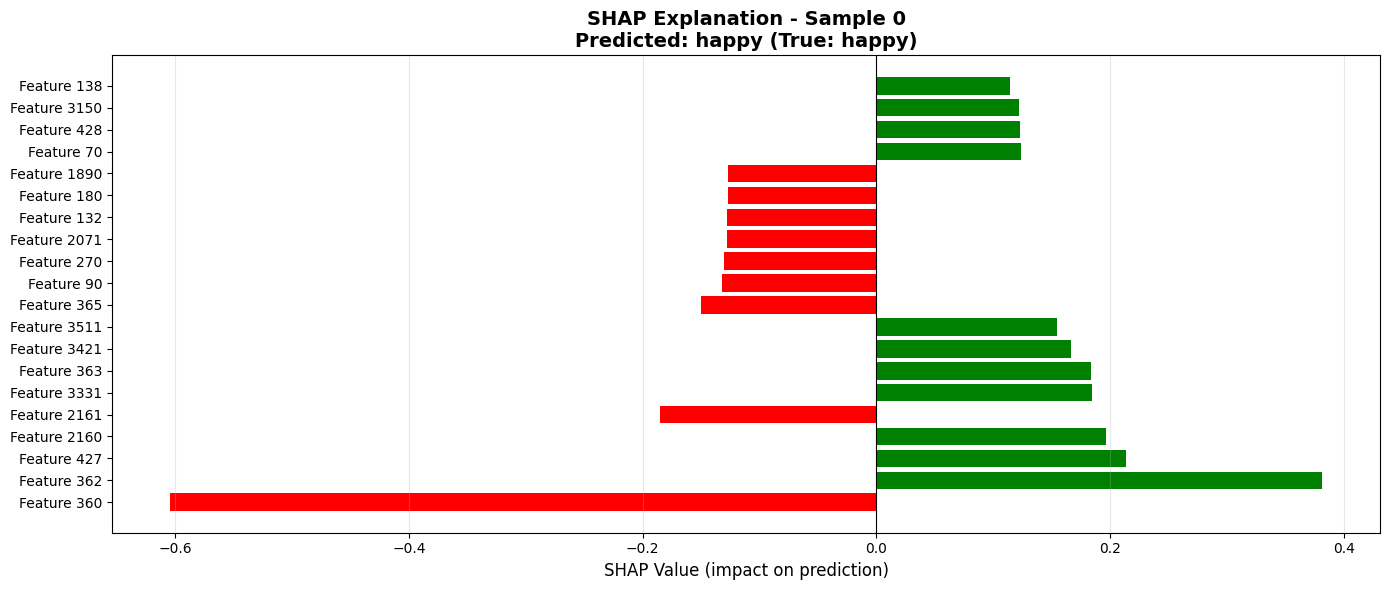


📊 LIME Explanation - Sample 0
   True: happy | Predicted: happy
   Using explanation key: 1 (available: [1])


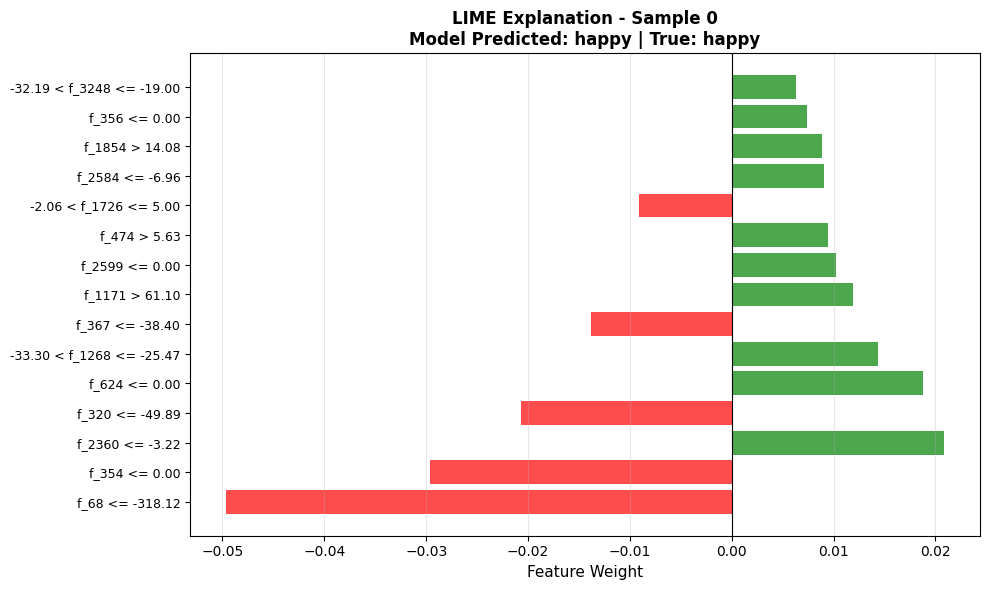


   Class Probabilities:
      angry: 0.0527
      disgust: 0.1212
      fearful: 0.2202
      happy: 0.4599 ⭐
      neutral: 0.0728
      sad: 0.0725
      surprise: 0.0006

🔒 Computing Trustworthy Metrics...
   Computing Faithfulness (AOPC)...
   Computing Robustness (Local Lipschitz)...
   Computing Acceptance (Sparsity)...
   Computing Acceptance (Consistency)...


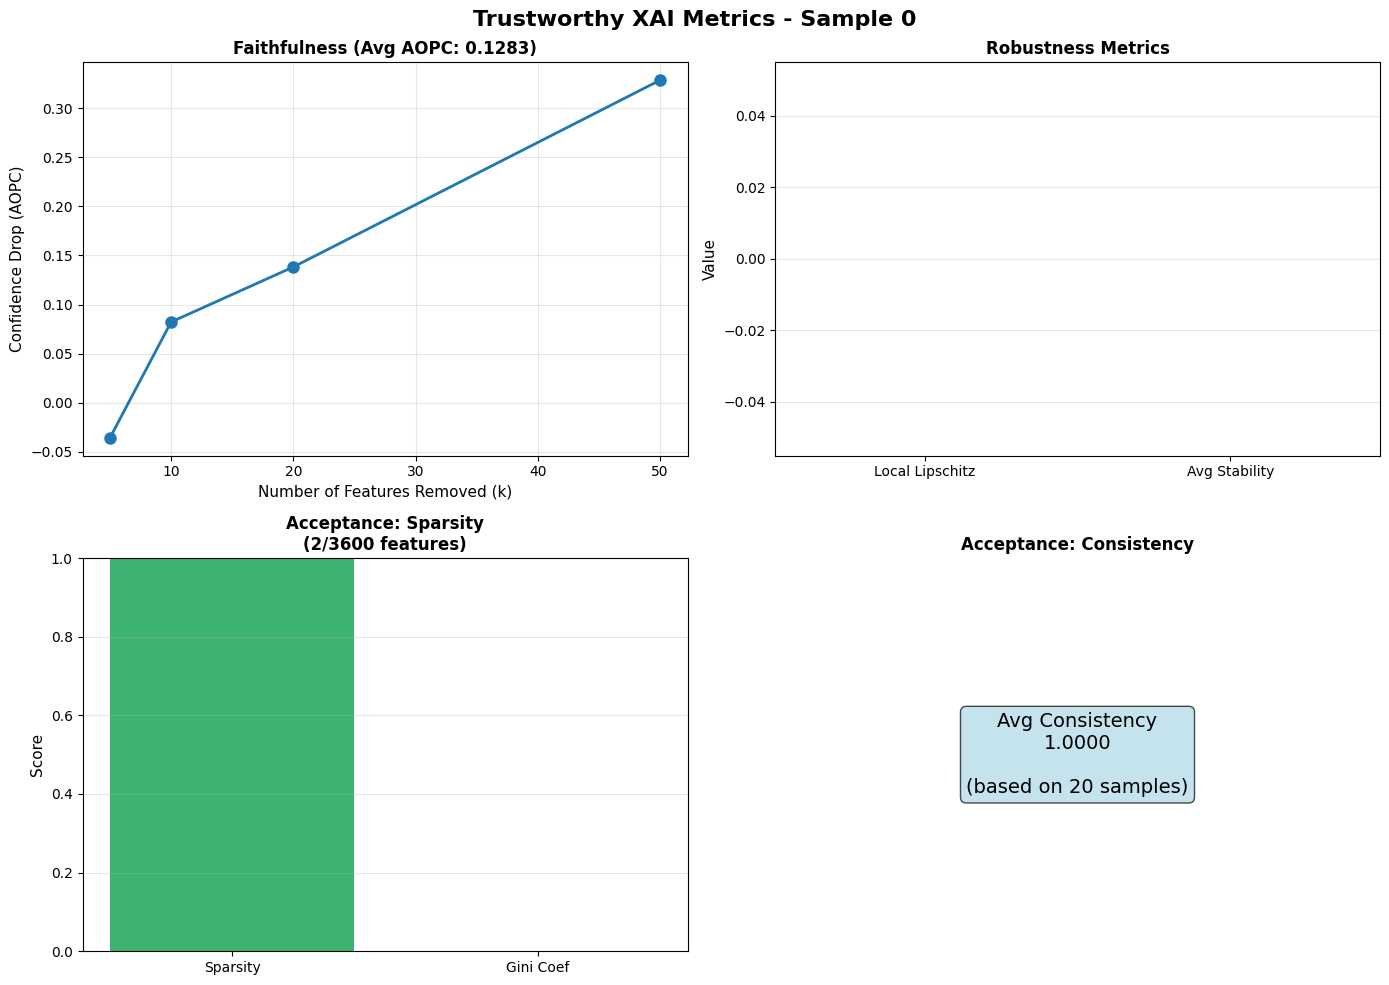


📋 SUMMARY for Sample 0:
   Faithfulness: 0.1283
   Sparsity: 0.9994
   LIME Fidelity: 0.0189

----------------------------------------------------------------------
🔍 SAMPLE 2/2 (Index: 10)
----------------------------------------------------------------------

📊 Individual SHAP Plot - Sample 1
   True: disgust | Predicted: angry


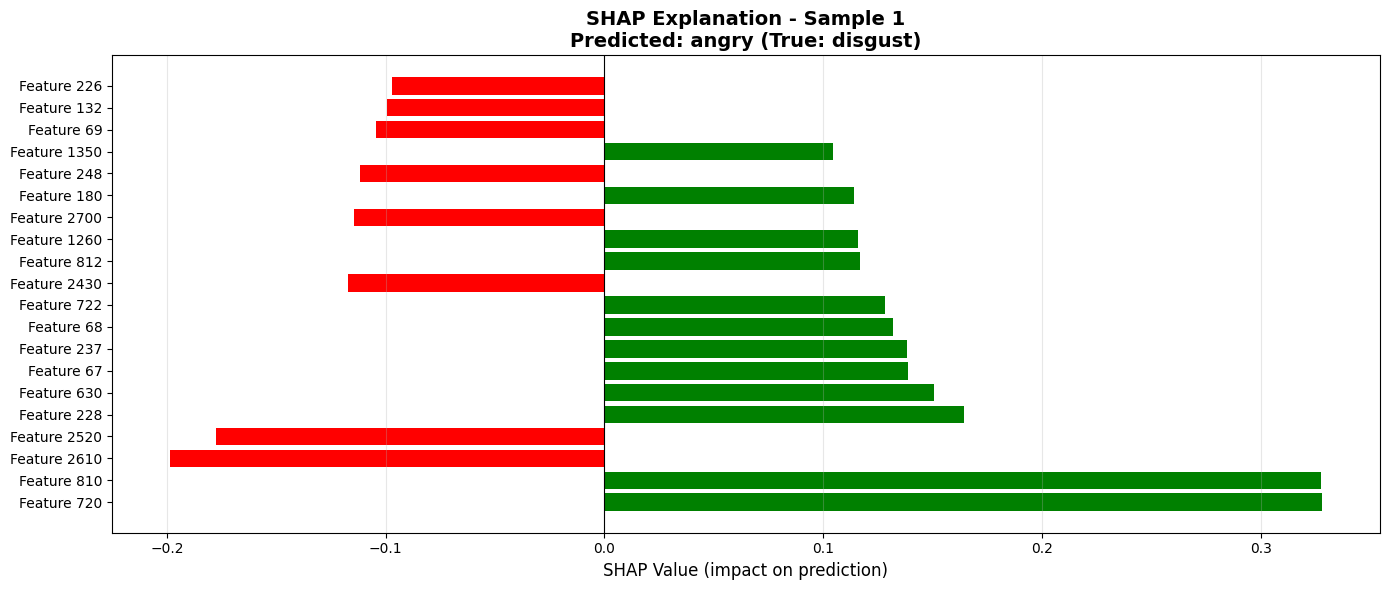


📊 LIME Explanation - Sample 10
   True: disgust | Predicted: angry
   Using explanation key: 1 (available: [1])


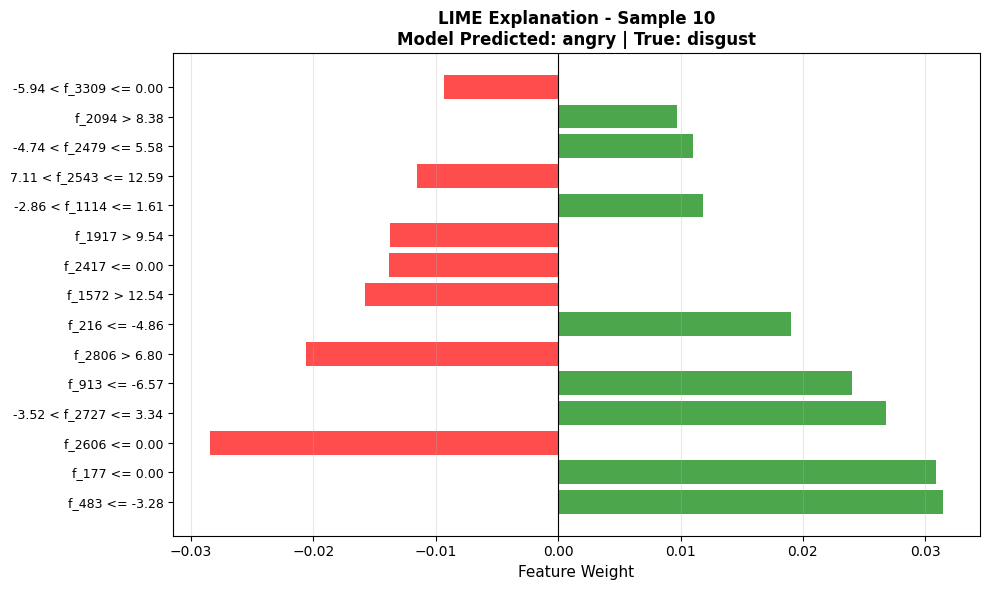


   Class Probabilities:
      angry: 0.8572 ⭐
      disgust: 0.1286
      fearful: 0.0027
      happy: 0.0105
      neutral: 0.0002
      sad: 0.0008
      surprise: 0.0000

🔒 Computing Trustworthy Metrics...
   Computing Faithfulness (AOPC)...
   Computing Robustness (Local Lipschitz)...
   Computing Acceptance (Sparsity)...
   Computing Acceptance (Consistency)...


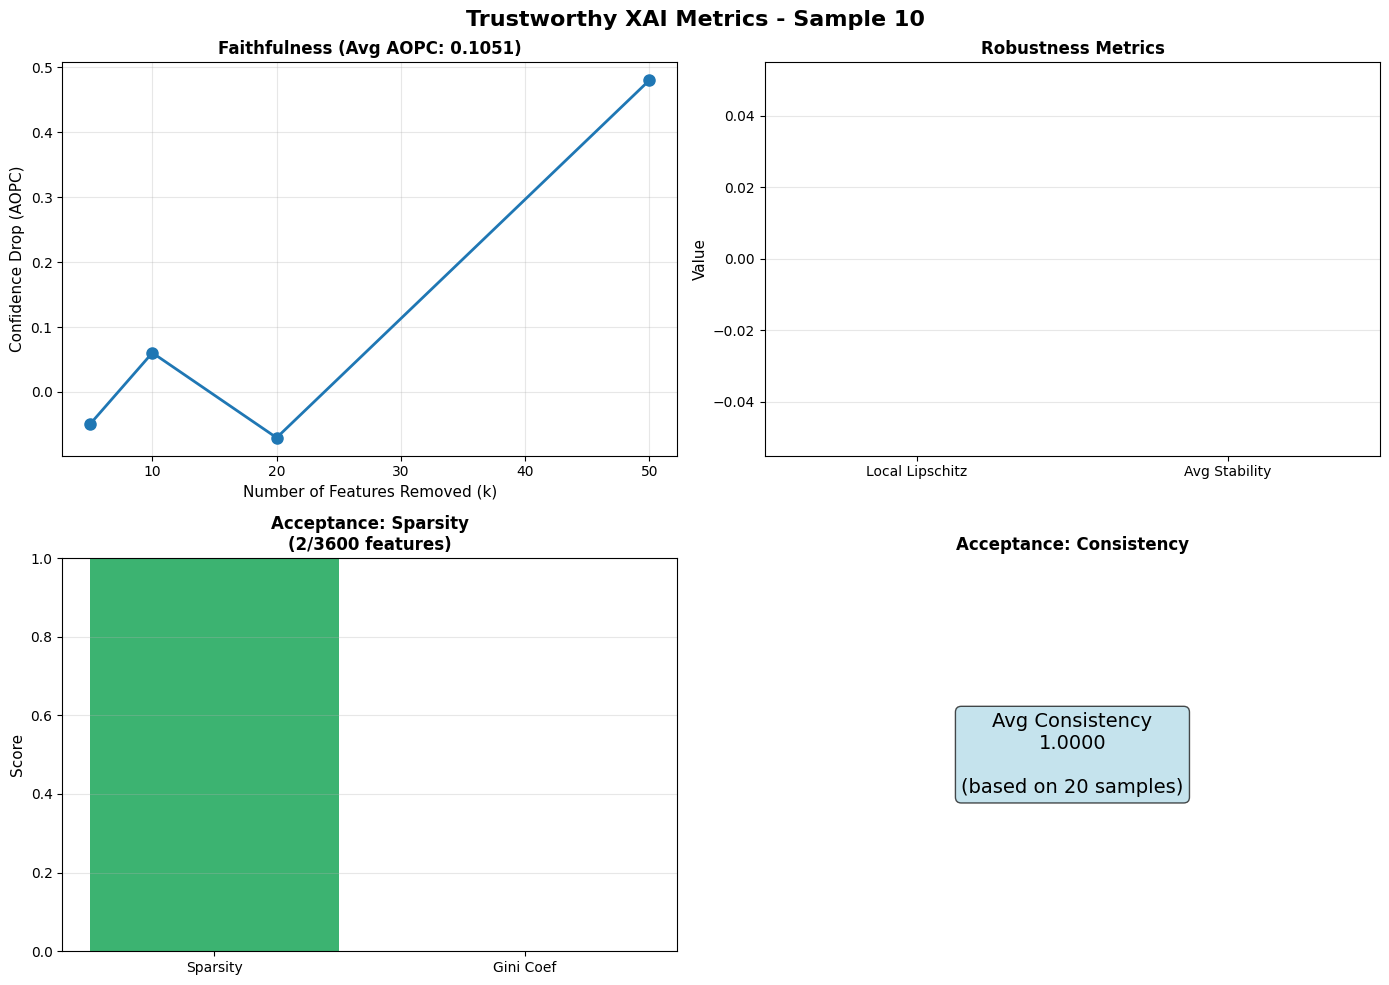


📋 SUMMARY for Sample 10:
   Faithfulness: 0.1051
   Sparsity: 0.9994
   LIME Fidelity: 0.0206

📊 AGGREGATE SUMMARY

🎯 Average Metrics:
   Faithfulness (AOPC): 0.1167 ± 0.0116
   Sparsity: 0.9994 ± 0.0000

✅ ANALYSIS COMPLETE!


In [ ]:
# =========================================================================
# RUN ANALYSIS WITH FIXED LIME
# =========================================================================

import numpy as np
import torch
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
import re

print("="*70)
print("🚀 STARTING EXPLAINABILITY ANALYSIS")
print("="*70)

# Helper function
def extract_conformer_features(model, X_data, device=None, batch_size=64):
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.eval()
    X_tensor = torch.tensor(X_data, dtype=torch.float32).to(device)
    feats = []
    with torch.no_grad():
        for i in range(0, len(X_tensor), batch_size):
            batch = X_tensor[i : i + batch_size]
            f = model(batch, output_type='features')
            feats.append(f.cpu().numpy())
    return np.vstack(feats)

# Prepare data
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y_int, test_size=0.2, stratify=y_int, random_state=42
)

print(f"Test set: {len(X_test)} samples, shape: {X_test.shape}")

class_names = list(label_encoder.classes_)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Select model
chosen_fusion = 'concat'
chosen_ensemble_model = ensemble_models[chosen_fusion]
chosen_ensemble_model.to(device)
chosen_ensemble_model.eval()

print(f"Using fusion: {chosen_fusion}, Device: {device}")

# Prediction function
def predict_proba_for_explainability(numpy_data):
    num_samples = numpy_data.shape[0]
    original_shape = (num_samples, X.shape[1], X.shape[2])
    numpy_data_3d = numpy_data.reshape(original_shape)

    feats_bilstm = bilstm_feature_model.predict(numpy_data_3d, verbose=0)
    feats_conf = extract_conformer_features(conformer_model_final, numpy_data_3d, device=device)

    f1 = torch.tensor(feats_bilstm, dtype=torch.float32).to(device)
    f2 = torch.tensor(feats_conf, dtype=torch.float32).to(device)

    with torch.no_grad():
        logits = chosen_ensemble_model(f1, f2)
        probabilities = F.softmax(logits, dim=1)

    return probabilities.detach().cpu().numpy()

print("✅ Setup complete\n")

# =========================================================================
# MANUAL ANALYSIS LOOP (avoiding the problematic function)
# =========================================================================

print("="*70)
print("🔍 RUNNING EXPLAINABILITY ANALYSIS")
print("="*70)

# Get predictions
X_test_flat = X_test.reshape(len(X_test), -1)
probs_all = predict_proba_for_explainability(X_test_flat)
preds_all = np.argmax(probs_all, axis=1)

from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, preds_all)
print(f"\nModel Accuracy: {accuracy*100:.2f}%")

# Select samples
correct_idx = np.where(preds_all == y_test)[0]
incorrect_idx = np.where(preds_all != y_test)[0]

num_samples = 3
selected_correct = correct_idx[:num_samples//2] if len(correct_idx) > 0 else []
selected_incorrect = incorrect_idx[:num_samples//2] if len(incorrect_idx) > 0 else []
selected_indices = np.concatenate([selected_correct, selected_incorrect])[:num_samples]

print(f"Selected {len(selected_indices)} samples for analysis\n")

# SHAP Analysis
print("="*70)
print("📈 SHAP ANALYSIS (Integrated Gradients)")
print("="*70)

shap_explainer = SHAPExplainer(bilstm_feature_model, conformer_model_final,
                                chosen_ensemble_model, device)

bg_indices = np.random.choice(len(X_test), size=20, replace=False)
X_background = X_test[bg_indices]

shap_values, X_explained = shap_explainer.explain_samples(
    X_background, X_test[selected_indices], class_names, max_display=num_samples
)

# LIME Analysis
print("\n" + "="*70)
print("🍋 LIME ANALYSIS")
print("="*70)

train_indices = np.random.choice(len(X_test), size=200, replace=False)
X_train_lime = X_test_flat[train_indices]

lime_explainer = LIMEExplainerFixed(predict_proba_for_explainability,
                                    X_train_lime, class_names)

# Trustworthy Metrics
print("\n" + "="*70)
print("🔒 TRUSTWORTHY XAI METRICS")
print("="*70)

trustworthy_evaluator = TrustworthyXAIMetrics(predict_proba_for_explainability,
                                               X_test.shape[1:])

all_metrics = []

# Analyze each sample
for i, sample_idx in enumerate(selected_indices):
    print("\n" + "-"*70)
    print(f"🔍 SAMPLE {i+1}/{len(selected_indices)} (Index: {sample_idx})")
    print("-"*70)

    true_class = y_test[sample_idx]
    pred_class = preds_all[sample_idx]

    X_sample_flat = X_test_flat[sample_idx]

    # SHAP
    shap_explainer.plot_individual_shap(
        shap_values, X_explained, i, true_class, pred_class, class_names
    )
    shap_importance = shap_values[int(pred_class)][i].flatten()

    # LIME
    lime_exp = lime_explainer.explain_instance(X_sample_flat, num_features=20, num_samples=3000)
    lime_explainer.plot_lime_explanation(lime_exp, sample_idx, true_class, pred_class)

    # Trustworthy Metrics
    print(f"\n🔒 Computing Trustworthy Metrics...")

    def get_importance(x_flat):
        return shap_importance

    same_class_indices = np.where(y_test == true_class)[0][:20]

    metrics = trustworthy_evaluator.compute_all_metrics(
        X_sample_flat, shap_importance,
        feature_importance_func=get_importance,
        same_class_indices=same_class_indices,
        X_all_flat=X_test_flat
    )

    trustworthy_evaluator.plot_trustworthy_metrics(metrics, sample_idx)

    all_metrics.append({
        'sample_idx': sample_idx,
        'true_class': class_names[int(true_class)],
        'pred_class': class_names[int(pred_class)],
        'metrics': metrics
    })

    print(f"\n📋 SUMMARY for Sample {sample_idx}:")
    print(f"   Faithfulness: {metrics['faithfulness']['avg_aopc']:.4f}")
    print(f"   Sparsity: {metrics['sparsity']['sparsity']:.4f}")
    print(f"   LIME Fidelity: {lime_explainer.get_surrogate_model_fidelity(lime_exp):.4f}")

# Final Summary
print("\n" + "="*70)
print("📊 AGGREGATE SUMMARY")
print("="*70)

faithfulness_scores = [m['metrics']['faithfulness']['avg_aopc'] for m in all_metrics]
sparsity_scores = [m['metrics']['sparsity']['sparsity'] for m in all_metrics]

print(f"\n🎯 Average Metrics:")
print(f"   Faithfulness (AOPC): {np.mean(faithfulness_scores):.4f} ± {np.std(faithfulness_scores):.4f}")
print(f"   Sparsity: {np.mean(sparsity_scores):.4f} ± {np.std(sparsity_scores):.4f}")

print("\n✅ ANALYSIS COMPLETE!")